In [100]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score


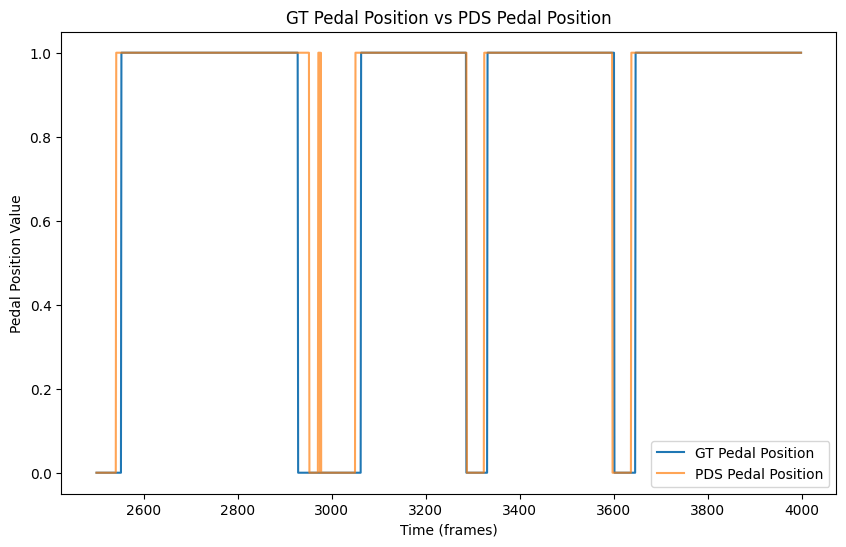

In [101]:

trials = ["t1","t2"]
base_path = "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid"

complete_df = pd.DataFrame()
for trial in trials:
    csv_path = f"{base_path}/{trial}/synched_data/final_annotation_{trial}.csv"

    df = pd.read_csv(csv_path)

    complete_df = pd.concat([complete_df, df], ignore_index=True)

# drop all rows with NaN values
complete_df = complete_df.dropna()

gt_pedal_column_name =  "console_pedal"
pds_pedal_column_name = "Pedal 5 Pressesd"

# drop all rows with -1 in console_pedal
complete_df = complete_df[complete_df[gt_pedal_column_name] != -1]

# invert the "Pedal Position" column
complete_df[pds_pedal_column_name] = 1 - complete_df[pds_pedal_column_name]

window_start = 2500
window_end = 4000

# filter the DataFrame for the specified window
filtered_df = complete_df.iloc[window_start:window_end]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df[gt_pedal_column_name], label='GT Pedal Position')
plt.xlabel('Time (frames)')
plt.ylabel('Pedal Position Value')

# compare console_pedal vs "Pedal Position" column
plt.plot(filtered_df[pds_pedal_column_name], label='PDS Pedal Position', alpha=0.7)
plt.legend()
plt.title('GT Pedal Position vs PDS Pedal Position')
plt.show()

## Compute F1, Precision, Recall and Accuracy for PDS pedal vs console

In [102]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, balanced_accuracy_score,
    cohen_kappa_score, matthews_corrcoef
)

# ---------- helpers ----------
def _align_by_xcorr(gt, pred, max_lag_frames=30):
    """Estimate a fixed lag via cross-correlation and shift pred to maximize agreement."""
    a = gt.astype(float) - gt.mean()
    b = pred.astype(float) - pred.mean()
    ac = np.correlate(a, b, mode='full')
    lags = np.arange(-len(a)+1, len(a))
    m = (lags >= -max_lag_frames) & (lags <= max_lag_frames)
    best_lag = int(lags[m][np.argmax(ac[m])])
    if best_lag > 0:
        pred_aligned = np.r_[np.zeros(best_lag, dtype=int), pred[:-best_lag]]
    elif best_lag < 0:
        pred_aligned = np.r_[pred[-best_lag:], np.zeros(-best_lag, dtype=int)]
    else:
        pred_aligned = pred
    return pred_aligned, best_lag

def _segments_from_binary(x):
    """Return [(start,end)] (inclusive) for contiguous 1-runs."""
    x = np.asarray(x, dtype=int)
    if len(x) == 0: return []
    starts = np.where((x[1:]==1) & (x[:-1]==0))[0] + 1
    ends   = np.where((x[1:]==0) & (x[:-1]==1))[0]
    if x[0]==1:  starts = np.r_[0, starts]
    if x[-1]==1: ends   = np.r_[ends, len(x)-1]
    return [(int(s), int(e)) for s, e in zip(starts, ends)]

def _safe_stats(values):
    if len(values) == 0:
        return dict(mean=np.nan, median=np.nan, std=np.nan)
    a = np.asarray(values, float)
    return dict(mean=float(a.mean()), median=float(np.median(a)), std=float(a.std(ddof=0)))

def _match_segments(gt_seg, pr_seg, onset_tol_frames=2, min_iou=0.5):
    """
    Greedy 1-1 matching by nearest onset. Returns:
      matches: list of dict for each GT segment (or None if no prediction)
      matched_pred_idx: set of pred indices matched with OK criteria
    A match is 'OK' if |onset_err| <= onset_tol_frames and IoU >= min_iou.
    """
    used = set()
    matches = []
    ok_pred = set()

    for gi, (gs, ge) in enumerate(gt_seg):
        if len(pr_seg) == 0:
            matches.append(None)
            continue

        # pick nearest pred by onset distance among unused ones
        cand = [(pi, ps, pe) for pi, (ps, pe) in enumerate(pr_seg) if pi not in used]
        if not cand:
            matches.append(None)
            continue
        pi, ps, pe = min(cand, key=lambda t: abs(t[1] - gs))

        onset_err = ps - gs
        overlap = max(0, min(ge, pe) - max(gs, ps) + 1)
        union = (ge - gs + 1) + (pe - ps + 1) - overlap
        iou = (overlap / union) if union > 0 else 0.0
        ok = (abs(onset_err) <= onset_tol_frames) and (iou >= min_iou)

        matches.append(dict(pred_idx=pi, onset_err=onset_err, offset_err=(pe - ge), iou=iou, ok=ok))
        used.add(pi)
        if ok:
            ok_pred.add(pi)

    return matches, ok_pred

# ---------- main evaluator ----------
def compute_pedal_metrics(
    gt_pedal, pds_pedal,
    fps=30.0,
    estimate_lag=True,
    max_lag_seconds=0.5,     # search window for fixed lag
    onset_tol_ms=50,         # tolerance for onset (segment-level)
    min_iou=0.5              # minimum temporal IoU for a segment to count
):
    gt = np.asarray(gt_pedal, dtype=int).flatten()
    pr = np.asarray(pds_pedal, dtype=int).flatten()
    assert gt.shape == pr.shape and gt.ndim == 1, "gt and pred must be same-length 1D arrays"

    # Optional fixed-lag alignment (applied to predictions)
    lag_frames = 0
    if estimate_lag:
        max_lag_frames = int(round(max_lag_seconds * fps))
        pr, lag_frames = _align_by_xcorr(gt, pr, max_lag_frames=max_lag_frames)

    # ---- frame-level metrics ----
    tn, fp, fn, tp = confusion_matrix(gt, pr, labels=[0, 1]).ravel()
    N = len(gt)
    accuracy = (tp + tn) / N if N > 0 else np.nan
    precision = precision_score(gt, pr, zero_division=0)
    recall = recall_score(gt, pr, zero_division=0)
    f1 = f1_score(gt, pr, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    bal_acc = balanced_accuracy_score(gt, pr)
    kappa = cohen_kappa_score(gt, pr)
    mcc = matthews_corrcoef(gt, pr) if (tp+tn+fp+fn) > 0 else np.nan

    # Temporal IoU over the active time (global)
    inter = np.logical_and(gt == 1, pr == 1).sum()
    union = np.logical_or(gt == 1, pr == 1).sum()
    temporal_iou = (inter / union) if union > 0 else (1.0 if inter == 0 else 0.0)

    # ---- segment / event metrics ----
    gt_seg = _segments_from_binary(gt)
    pr_seg = _segments_from_binary(pr)

    onset_tol_frames = int(round((onset_tol_ms / 1000.0) * fps))
    matches, ok_pred = _match_segments(gt_seg, pr_seg, onset_tol_frames=onset_tol_frames, min_iou=min_iou)

    # segment-level recall (tolerance)
    num_gt = len(gt_seg)
    ok_count = sum(1 for m in matches if (m is not None and m["ok"]))
    seg_recall = ok_count / num_gt if num_gt > 0 else (1.0 if len(pr_seg) == 0 else 0.0)

    # segment-level precision (tolerance)
    num_pr = len(pr_seg)
    seg_precision = len(ok_pred) / num_pr if num_pr > 0 else (1.0 if num_gt == 0 else 0.0)

    seg_f1 = (2 * seg_precision * seg_recall / (seg_precision + seg_recall)) if (seg_precision + seg_recall) > 0 else 0.0

    # onset/offset errors (frames)
    onset_errs = [m["onset_err"] for m in matches if m is not None]
    offset_errs = [m["offset_err"] for m in matches if m is not None]
    onset_stats_f = _safe_stats(onset_errs)
    offset_stats_f = _safe_stats(offset_errs)

    # convert to ms
    frame_to_ms = 1000.0 / fps if fps > 0 else np.nan
    onset_stats_ms = {k: (v * frame_to_ms if pd.notna(v) else np.nan) for k, v in onset_stats_f.items()}
    offset_stats_ms = {k: (v * frame_to_ms if pd.notna(v) else np.nan) for k, v in offset_stats_f.items()}

    # spurious activation rate (per minute): predicted segments not matched OK
    spurious = num_pr - len(ok_pred)
    duration_min = (N / fps) / 60.0 if fps > 0 else np.nan
    spurious_per_min = (spurious / duration_min) if duration_min and duration_min > 0 else np.nan

    # package results
    metrics = dict(
        # frame-level
        frames=N, tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn),
        accuracy=float(accuracy),
        precision=float(precision), recall=float(recall), f1=float(f1),
        specificity=float(specificity), balanced_accuracy=float(bal_acc),
        cohen_kappa=float(kappa), mcc=float(mcc),
        temporal_iou=float(temporal_iou),
        # alignment
        lag_frames=int(lag_frames),
        lag_ms=float(lag_frames * frame_to_ms) if fps > 0 else np.nan,
        # segments
        gt_segments=num_gt, pred_segments=num_pr,
        seg_precision=float(seg_precision), seg_recall=float(seg_recall), seg_f1=float(seg_f1),
        onset_tol_ms=float(onset_tol_ms), min_iou=float(min_iou),
        onset_err_frames=onset_stats_f, offset_err_frames=offset_stats_f,
        onset_err_ms=onset_stats_ms, offset_err_ms=offset_stats_ms,
        spurious_per_min=float(spurious_per_min)
    )
    return metrics

# ---------- your original wrapper (kept) ----------
def compute_metrics(gt_pedal, pds_pedal):
    """Keeps your original four metrics."""
    f1 = f1_score(gt_pedal, pds_pedal, zero_division=0)
    precision = precision_score(gt_pedal, pds_pedal, zero_division=0)
    recall = recall_score(gt_pedal, pds_pedal, zero_division=0)
    accuracy = accuracy_score(gt_pedal, pds_pedal)
    return f1, precision, recall, accuracy



# --- NEW: combine & evaluate multiple pedals at once ---
def combine_pedals_binary(df: pd.DataFrame, gt_pedals: list[str], pedal_mapping: dict[str, str],
                          mode: str = "any") -> tuple[np.ndarray, np.ndarray]:
    """
    Combine multiple pedal columns into single GT and PDS binary arrays.
    mode = "any" -> logical OR across pedals; "all" -> logical AND.
    """
    if not gt_pedals:
        raise ValueError("gt_pedals must be a non-empty list of GT pedal names.")

    # validate columns
    missing_gt = [p for p in gt_pedals if p not in df.columns]
    missing_pds = [pedal_mapping[p] for p in gt_pedals if pedal_mapping[p] not in df.columns]
    if missing_gt or missing_pds:
        raise KeyError(f"Missing columns. GT: {missing_gt}  PDS: {missing_pds}")

    op = np.logical_or if mode.lower() == "any" else np.logical_and

    # start with first pedal then fold
    gt_comb = df[gt_pedals[0]].astype(int).values
    pds_comb = df[pedal_mapping[gt_pedals[0]]].astype(int).values

    for p in gt_pedals[1:]:
        gt_comb = op(gt_comb, df[p].astype(int).values).astype(int)
        pds_comb = op(pds_comb, df[pedal_mapping[p]].astype(int).values).astype(int)

    return gt_comb.astype(int), pds_comb.astype(int)


def compute_metrics_multi(complete_df: pd.DataFrame,
                          gt_pedals: list[str],
                          pedal_mapping: dict[str, str],
                          fps: float = 30.0,
                          estimate_lag: bool = True,
                          max_lag_seconds: float = 0.5,
                          onset_tol_ms: int = 50,
                          min_iou: float = 0.5,
                          mode: str = "any") -> dict:
    """
    Compute the detailed metrics on the combined signal of multiple pedals.
    Returns the full dict from compute_pedal_metrics plus bookkeeping.
    """
    gt_comb, pds_comb = combine_pedals_binary(complete_df, gt_pedals, pedal_mapping, mode=mode)

    metrics = compute_pedal_metrics(
        gt_comb, pds_comb,
        fps=fps,
        estimate_lag=estimate_lag,
        max_lag_seconds=max_lag_seconds,
        onset_tol_ms=onset_tol_ms,
        min_iou=min_iou
    )
    metrics["combined_pedals"] = list(gt_pedals)
    metrics["combine_mode"] = mode.lower()
    return metrics









# ---------- example usage ----------
f1, precision, recall, accuracy = compute_metrics(complete_df[gt_pedal_column_name], complete_df[pds_pedal_column_name])
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")

metrics = compute_pedal_metrics(
    complete_df[gt_pedal_column_name].values,
    complete_df[pds_pedal_column_name].values,
    fps=30.0,                # <-- set your true frame rate
    estimate_lag=True,       # set False if you already synchronized
    max_lag_seconds=0.5,     # search ±0.5 s
    onset_tol_ms=50,         # ±50 ms onset tolerance
    min_iou=0.5              # ≥50% overlap to count
)
print(pd.Series(metrics))

results_dir = "pedal_accuracy_results"
os.makedirs(results_dir, exist_ok=True)

# save metrics to CSV
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(f"{results_dir}/pedal_accuracy_metrics.csv", index=False)

F1 Score: 0.8479
Precision: 0.7715
Recall: 0.9412
Accuracy: 0.7642
frames                                                           20603
tp                                                               13616
fp                                                                3937
tn                                                                2273
fn                                                                 777
accuracy                                                      0.771198
precision                                                     0.775708
recall                                                        0.946015
f1                                                            0.852438
specificity                                                   0.366023
balanced_accuracy                                             0.656019
cohen_kappa                                                   0.364809
mcc                                                           0.403184
temporal_i

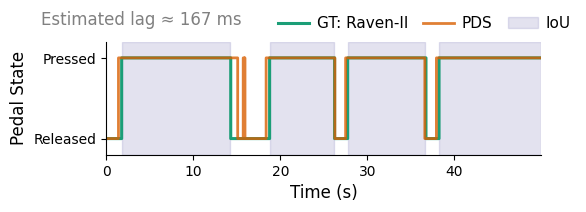

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_pedal_signals(complete_df, gt_pedal_column_name, pds_pedal_column_name, window_start, window_end, platform, results_dir):
    # --- Config ---
    fps = 30.0  # adjust to your actual frame rate

    # --- Extract window ---
    filtered_df = complete_df.iloc[window_start:window_end].copy()
    frames = np.arange(window_start, window_end)
    time_s = (frames - window_start) / fps  # convert to seconds for x-axis

    gt = filtered_df[gt_pedal_column_name].to_numpy()
    pds = filtered_df[pds_pedal_column_name].to_numpy()

    # --- Figure styling ---
    sns.reset_orig()

    plt.figure(figsize=(6, 2.5))

    # --- Plot signals as filled steps for clarity ---
    plt.step(time_s, gt, where='post', linewidth=2.2, color='#1b9e77', label=f'GT: {platform}')
    plt.step(time_s, pds, where='post', linewidth=2.0, color='#d95f02', alpha=0.8, label='PDS')

    # Optional shading for overlapping active regions
    overlap = np.logical_and(gt == 1, pds == 1)
    plt.fill_between(time_s, 0, 1,
                    where=overlap, color='#7570b3', alpha=0.2, transform=plt.gca().get_xaxis_transform(),
                    label='IoU')

    # --- Axis & labels ---
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Pedal State', fontsize=12)
    plt.yticks([0, 1], ['Released', 'Pressed'])
    plt.ylim(-0.2, 1.2)
    plt.xlim(time_s[0], time_s[-1])

    # --- Legend & title ---
    # plt.legend(loc='lower right', frameon=True, fontsize=11)
    plt.legend(
        loc='upper right',
        bbox_to_anchor=(1.1, 1.35),  # move above the top axis
        ncol=3,                    # all items in one row
        frameon=False,
        fontsize=11,
        handletextpad=0.5,
        columnspacing=1.0
    )

    # --- Annotate lag if known ---
    lag_frames = 5
    lag_ms = lag_frames * 1000 / fps
    plt.text(-0.15, 1.15, f'Estimated lag ≈ {lag_ms:.0f} ms',
            transform=plt.gca().transAxes, fontsize=12, color='gray')

    # --- Layout ---
    sns.despine()
    plt.tight_layout()
    # save figure as pdf
    plt.savefig(f"{results_dir}/pedal_accuracy_comparison.pdf", format='pdf', dpi=300)

    plt.show()

window_start = 2500
window_end = 4000
raven_df = complete_df  # assuming complete_df is for Raven-II platform
gt_pedal_column_name_raven = gt_pedal_column_name
pds_pedal_column_name_raven = pds_pedal_column_name

plot_pedal_signals(raven_df, gt_pedal_column_name_raven, pds_pedal_column_name_raven, window_start, window_end, platform="Raven-II", results_dir=results_dir)


# Bootcamp Data Evaluation

In [104]:
# import pandas as pd

# data_path_1 = "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/Bowel_S207_T2_2024-07-18/pedal_detection.csv"
# data_path_2 = "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S116_T1_2024-07-19/pedal_detection.csv"

# # Load both
# df1 = pd.read_csv(data_path_1)
# df2 = pd.read_csv(data_path_2)

# # Align to the shorter length
# min_len = min(len(df1), len(df2))
# df1 = df1.iloc[:min_len].copy()
# df2 = df2.iloc[:min_len].copy()

# # Add only the specified column from df2, with a distinct name
# column_to_merge = "Upper Right"
# df1[f"{column_to_merge}_from_df2"] = df2[column_to_merge].values

# # df1 now contains all original columns plus the one merged from df2
# print(df1.head())
# merged_df = df1

/tmp/ipykernel_595659/1459704692.py:7: DtypeWarning: Columns (64,65,66,67,68) have mixed types. Specify dtype option on import or set low_memory=False.
  pds_sync_df = pd.read_csv(bootcamp_pds_sync_path)


['Frame Num', 'Upper Left', 'Lower Left', 'Upper Right', 'Lower Right']
['Pedal 1 Pressed', 'Pedal 2 Pressed', 'Pedal 3 Pressed', 'Pedal 4 Pressed', 'obs_frame_idx']
['Frame Num', 'Upper Left', 'Lower Left', 'Upper Right', 'Lower Right', 'Pedal 1 Pressed', 'Pedal 2 Pressed', 'Pedal 3 Pressed', 'Pedal 4 Pressed', 'obs_frame_idx']
Metrics for Lower Right:
F1 Score: 0.7461
Precision: 0.5979
Recall: 0.9921
Accuracy: 0.9941
Detailed Metrics for Lower Right:
frames                                                          129991
tp                                                                1131
fp                                                                 759
tn                                                              128093
fn                                                                   8
accuracy                                                        0.9941
precision                                                     0.598413
recall                                        

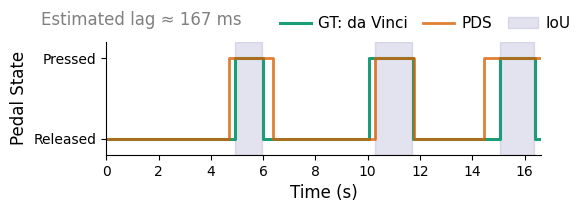

In [105]:
# bootcamp path
bootcamp_pds_gt_path = "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S116_T1_2024-07-19/pedal_detection.csv"
bootcamp_pds_sync_path = "/standard/UVA-DSA/MIDAS/Organized/Bootcamp/SuturingV2/Processed/S116_T1/synched_data/final_annotation_S116_T1.csv"


gt_pds_df = pd.read_csv(bootcamp_pds_gt_path)
pds_sync_df = pd.read_csv(bootcamp_pds_sync_path)

pedal_mapping = {
    'Upper Left': 'Pedal 1 Pressed',
    'Upper Right': 'Pedal 2 Pressed',
    'Lower Left': 'Pedal 3 Pressed',
    'Lower Right': 'Pedal 4 Pressed'
}


# get only the relevant columns from pds_sync_df based on pedal_mapping values
relevant_pds_columns = list(pedal_mapping.values())
relevant_pds_columns.append('obs_frame_idx')  # also keep obs_frame_idx for merging

pds_sync_df = pds_sync_df[relevant_pds_columns]

print(gt_pds_df.columns.tolist())
print(pds_sync_df.columns.tolist())

# merge dataframes on frame index
merged_df = pd.merge(gt_pds_df, pds_sync_df, left_on='Frame Num', right_on='obs_frame_idx', how='inner')  
print(merged_df.columns.tolist())

# plot comparison for each pedal
def PDSvsGT(merged_df):
    for gt_pedal, pds_pedal in pedal_mapping.items():
        plt.figure(figsize=(10, 4))
        plt.plot(merged_df['Frame Num'], merged_df[gt_pedal], label='GT Pedal Position')
        plt.plot(merged_df['Frame Num'], merged_df[pds_pedal], label='PDS Pedal Position', alpha=0.7)
        plt.xlabel('Frame Number')
        plt.ylabel('Pedal Position Value')
        plt.title(f'GT Pedal Position vs PDS Pedal Position: {gt_pedal}')
        plt.legend()
        plt.show()

# PDSvsGT(merged_df)

# selected pedal
selected_gt_pedal = 'Lower Right'
selected_pds_pedal = pedal_mapping[selected_gt_pedal]

# compute metrics for selected pedal
f1, precision, recall, accuracy = compute_metrics(merged_df[selected_gt_pedal], merged_df[selected_pds_pedal])
print(f"Metrics for {selected_gt_pedal}:")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")

# compute detailed metrics
detailed_metrics = compute_pedal_metrics(
    merged_df[selected_gt_pedal].values,
    merged_df[selected_pds_pedal].values,
    fps=30.0,                # <-- set your true frame rate
    estimate_lag=True,       # set False if you already synchronized
    max_lag_seconds=0.5,     # search ±0.5 s
    onset_tol_ms=50,         # ±50 ms onset tolerance
    min_iou=0.5              # ≥50% overlap to count
)
print(f"Detailed Metrics for {selected_gt_pedal}:")
print(pd.Series(detailed_metrics))

# plot pedal signals for selected pedal
results_dir = "bootcamp_pedal_accuracy_results"
os.makedirs(results_dir, exist_ok=True)
window_start = 3000
window_end = 3500

davinci_df = merged_df  # assuming merged_df is for da Vinci platform
gt_pedal_column_name_dv = selected_gt_pedal
pds_pedal_column_name_dv = selected_pds_pedal
    
plot_pedal_signals(davinci_df, gt_pedal_column_name_dv, pds_pedal_column_name_dv, window_start=window_start, window_end=window_end, platform="da Vinci", results_dir=results_dir)

In [106]:
# do above for all bootcamp files in a loop


# trials list
pds_trials = [
    "/standard/UVA-DSA/MIDAS/Organized/Bootcamp/SuturingV2/Processed/S116_T1",
    "/standard/UVA-DSA/MIDAS/Organized/Bootcamp/SuturingV2/Processed/S219_T1"
]

gt_pds_trials = [
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S116_T1_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S219_T1_2024-07-19"
]


complete_df = pd.DataFrame()

for pds_trial, gt_trial in zip(pds_trials, gt_pds_trials):
    gt_pds_df = pd.read_csv(f"{gt_trial}/pedal_detection.csv")
    trial_id = pds_trial.split("/")[-1]
    print(f"Processing trial: {trial_id}")
    pds_sync_df = pd.read_csv(f"{pds_trial}/synched_data/final_annotation_{trial_id}.csv")

    # get only the relevant columns from pds_sync_df based on pedal_mapping values
    relevant_pds_columns = list(pedal_mapping.values())
    relevant_pds_columns.append('obs_frame_idx')  # also keep obs_frame_idx for merging
    pds_sync_df = pds_sync_df[relevant_pds_columns]
    # merge dataframes on frame index
    merged_df = pd.merge(gt_pds_df, pds_sync_df, left_on='Frame Num', right_on='obs_frame_idx', how='inner')  
    merged_df['trial_id'] = trial_id  # add trial identifier
    complete_df = pd.concat([complete_df, merged_df], ignore_index=True)

# drop all rows with NaN values
complete_df = complete_df.dropna()

selected_gt_pedal = 'Lower Right'
selected_pds_pedal = pedal_mapping[selected_gt_pedal]

# compute metrics for selected pedal
f1, precision, recall, accuracy = compute_metrics(complete_df[selected_gt_pedal], complete_df[selected_pds_pedal])
print(f"Overall Metrics for {selected_gt_pedal}:")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")

detailed_metrics = compute_pedal_metrics(
    complete_df[selected_gt_pedal].values,
    complete_df[selected_pds_pedal].values,
    fps=30.0,                # <-- set your true frame rate
    estimate_lag=True,       # set False if you already synchronized
    max_lag_seconds=0.5,     # search ±0.5 s
    onset_tol_ms=50,         # ±50 ms onset tolerance
    min_iou=0.5              # ≥50% overlap to count
)
print(f"Overall Detailed Metrics for {selected_gt_pedal}:")
print(pd.Series(detailed_metrics))

Processing trial: S116_T1


/tmp/ipykernel_595659/774263170.py:22: DtypeWarning: Columns (64,65,66,67,68) have mixed types. Specify dtype option on import or set low_memory=False.
  pds_sync_df = pd.read_csv(f"{pds_trial}/synched_data/final_annotation_{trial_id}.csv")


Processing trial: S219_T1


/tmp/ipykernel_595659/774263170.py:22: DtypeWarning: Columns (62,63,64,65,66) have mixed types. Specify dtype option on import or set low_memory=False.
  pds_sync_df = pd.read_csv(f"{pds_trial}/synched_data/final_annotation_{trial_id}.csv")


Overall Metrics for Lower Right:
F1 Score: 0.7461
Precision: 0.5979
Recall: 0.9921
Accuracy: 0.9953
Overall Detailed Metrics for Lower Right:
frames                                                          163223
tp                                                                1131
fp                                                                 759
tn                                                              161325
fn                                                                   8
accuracy                                                      0.995301
precision                                                     0.598413
recall                                                        0.992976
f1                                                            0.746781
specificity                                                   0.995317
balanced_accuracy                                             0.994147
cohen_kappa                                                   0.744557
mcc   

/tmp/ipykernel_595659/3913835639.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


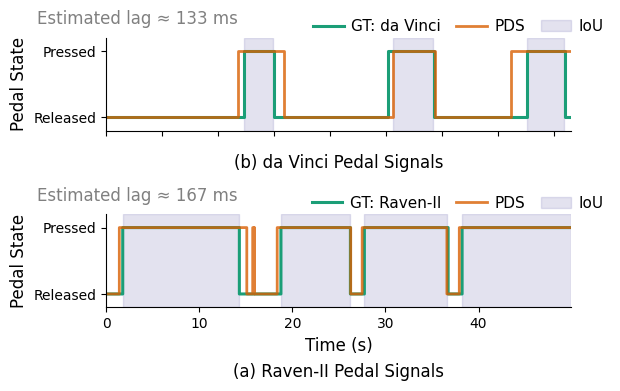

Combined (ANY) metrics:
 frames                                                          163223
tp                                                                1131
fp                                                                 759
tn                                                              161325
fn                                                                   8
accuracy                                                      0.995301
precision                                                     0.598413
recall                                                        0.992976
f1                                                            0.746781
specificity                                                   0.995317
balanced_accuracy                                             0.994147
cohen_kappa                                                   0.744557
mcc                                                           0.768998
temporal_iou                                        

/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/site-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/home/cjh9fw/conda/envs/egoexoems/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the c

In [107]:
# do both plot_pedal_signals for two datasets in one figure stacked vertically and share the x-axis label

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_pedal_signals_compare(
    cfg1: dict,
    cfg2: dict,
    results_dir: str,
    filename: str = "pedal_accuracy_comparison_two_datasets.pdf",
):
    """
    Plot two pedal-signal timelines stacked vertically.
    Each cfg is a dict with:
      - 'complete_df': DataFrame
      - 'gt_pedal_column_name': str
      - 'pds_pedal_column_name': str
      - 'window_start': int
      - 'window_end': int
      - 'platform': str
      - (optional) 'fps': float (default 30.0)
      - (optional) 'lag_frames': int (default 5)
    """

    def _extract(cfg):
        df      = cfg['complete_df']
        ws      = cfg['window_start']
        we      = cfg['window_end']
        fps     = cfg.get('fps', 30.0)
        frames  = np.arange(ws, we)
        time_s  = (frames - ws) / fps
        filtered_df = df.iloc[ws:we].copy()
        gt   = filtered_df[cfg['gt_pedal_column_name']].to_numpy()
        pds  = filtered_df[cfg['pds_pedal_column_name']].to_numpy()
        lag_frames = cfg.get('lag_frames', 5)
        platform   = cfg['platform']
        return time_s, gt, pds, fps, lag_frames, platform

    # --- Extract both ---
    t1, gt1, pds1, fps1, lag1, plat1 = _extract(cfg1)
    t2, gt2, pds2, fps2, lag2, plat2 = _extract(cfg2)

    # --- Styling reset ---
    sns.reset_orig()

    # --- Figure & axes ---
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(6, 3.5), sharex=False,
        gridspec_kw={'hspace': 0.9}
    )

    # Common style values
    gt_color = '#1b9e77'
    pds_color = '#d95f02'
    overlap_color = '#7570b3'

    # Helper to draw one panel
    def _draw_panel(ax, time_s, gt, pds, fps, lag_frames, platform):
        ax.step(time_s, gt, where='post', linewidth=2.2, color=gt_color, label=f'GT: {platform}')
        ax.step(time_s, pds, where='post', linewidth=2.0, color=pds_color, alpha=0.8, label='PDS')

        overlap = np.logical_and(gt == 1, pds == 1)
        ax.fill_between(
            time_s, 0, 1,
            where=overlap,
            color=overlap_color, alpha=0.2,
            transform=ax.get_xaxis_transform(),
            label='IoU'
        )

        ax.set_ylabel('Pedal State', fontsize=12)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['Released', 'Pressed'])
        ax.set_ylim(-0.2, 1.2)
        ax.set_xlim(time_s[0], time_s[-1])

        if platform == "Raven-II":
            ax.text(
                0.5, -0.6,                # x, y (in axis fraction coordinates)
                f"(a) {platform} Pedal Signals", 
                fontsize=12, 
                ha='center', va='top', 
                transform=ax.transAxes
            )
        else:
            ax.text(
                0.5, -0.25,                # x, y (in axis fraction coordinates)
                f"(b) {platform} Pedal Signals", 
                fontsize=12, 
                ha='center', va='top', 
                transform=ax.transAxes
            )

        # Legend above the axis (one row, frameless), matching your original placement
        ax.legend(
            loc='upper right',
            bbox_to_anchor=(1.1, 1.35),
            ncol=3,
            frameon=False,
            fontsize=11,
            handletextpad=0.5,
            columnspacing=1.0
        )

        # Lag annotation
        lag_ms = lag_frames * 1000.0 / fps
        ax.text(
            -0.15, 1.15, f'Estimated lag ≈ {lag_ms:.0f} ms',
            transform=ax.transAxes, fontsize=12, color='gray'
        )

        sns.despine(ax=ax)

    # Draw both panels
    _draw_panel(ax1, t1, gt1, pds1, fps1, lag1, plat1)
    _draw_panel(ax2, t2, gt2, pds2, fps2, lag2, plat2)

    # Top axis: hide x tick labels (you asked to share the x-axis label, not ticks)
    ax1.set_xticklabels([])

    # Bottom axis: keep ticks; global shared xlabel for the figure
    ax2.set_xlabel('Time (s)', fontsize=12)

    plt.tight_layout()
    out_path = f"{results_dir.rstrip('/')}/{filename}"
    plt.savefig(out_path, format='png', dpi=300, bbox_inches='tight')
    plt.show()
    return out_path

# -------------------
# Example usage:


cfg_raven = dict(
    complete_df=raven_df,
    gt_pedal_column_name=gt_pedal_column_name_raven,
    pds_pedal_column_name=pds_pedal_column_name_raven,
    window_start=2500,
    window_end=4000,
    platform="Raven-II",
    fps=30.0,
    lag_frames=5
)

cfg_dv = dict(
    complete_df=davinci_df,
    gt_pedal_column_name=gt_pedal_column_name_dv,
    pds_pedal_column_name=pds_pedal_column_name_dv,
    window_start=3000,
    window_end=3500,
    platform="da Vinci",
    fps=30.0,
    lag_frames=4
)

results_pdf = plot_pedal_signals_compare(cfg_dv, cfg_raven, results_dir, filename="raven_vs_dv_pedals.png")


# choose any set of pedals (1, 2, or more)
group = ['Lower Right', 'Upper Left']  # e.g., combine LR and UL
res_any = compute_metrics_multi(
    complete_df, group, pedal_mapping,
    fps=30.0, estimate_lag=True, max_lag_seconds=0.5,
    onset_tol_ms=50, min_iou=0.5, mode="any"   # OR-combine
)
print("Combined (ANY) metrics:\n", pd.Series(res_any))

# AND-combined (only when all selected pedals are pressed simultaneously)
res_all = compute_metrics_multi(
    complete_df, group, pedal_mapping, mode="all"
)
print("Combined (ALL) metrics:\n", pd.Series(res_all))


/tmp/ipykernel_595659/2689061476.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


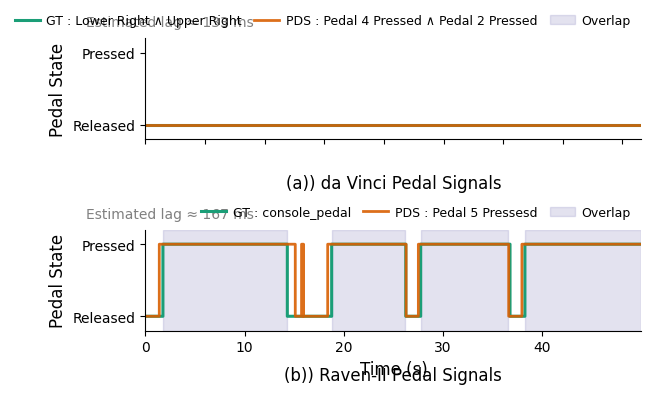

In [108]:
# do both plot_pedal_signals for two datasets in one figure stacked vertically and share the x-axis label

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from typing import List, Union

def _as_list(x: Union[str, List[str]]) -> List[str]:
    if isinstance(x, str):
        return [x]
    if isinstance(x, (list, tuple)):
        return list(x)
    raise TypeError("Pedal column names must be a string or list of strings.")

def _combine_binary_cols(df: pd.DataFrame, cols: List[str], mode: str = "any") -> np.ndarray:
    """Combine multiple binary columns into a single 0/1 vector using OR ('any') or AND ('all')."""
    if len(cols) == 0:
        raise ValueError("No columns provided to combine.")
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in DataFrame: {missing}")
    data = df[cols].astype(int).to_numpy()
    if mode.lower() == "any":
        combined = (data.sum(axis=1) > 0).astype(int)
    elif mode.lower() == "all":
        combined = (data.sum(axis=1) == data.shape[1]).astype(int)
    else:
        raise ValueError("mode must be 'any' or 'all'.")
    return combined

def plot_pedal_signals_compare(
    cfg1: dict,
    cfg2: dict,
    results_dir: str,
    filename: str = "pedal_accuracy_comparison_two_datasets.pdf",
):
    """
    Plot two pedal-signal timelines stacked vertically, supporting multi-pedal combinations.

    Each cfg is a dict with:
      - 'complete_df': DataFrame (must include the pedal columns)
      - 'gt_pedal_column_names': str | list[str]   (GT pedal column(s) to combine)
      - 'pds_pedal_column_names': str | list[str]  (PDS pedal column(s) to combine)
      - 'window_start': int  (inclusive)
      - 'window_end': int    (exclusive)
      - 'platform': str
      - (optional) 'fps': float (default 30.0)
      - (optional) 'lag_frames': int (default 5)   [displayed as annotation only]
      - (optional) 'combine_mode': 'any' or 'all' (default 'any')

    The GT and PDS signals are each combined across their specified columns using combine_mode.
    """

    def _extract(cfg):
        df       = cfg['complete_df']
        ws       = int(cfg['window_start'])
        we       = int(cfg['window_end'])
        fps      = float(cfg.get('fps', 30.0))
        lag_fr   = int(cfg.get('lag_frames', 5))
        platform = cfg['platform']
        mode     = cfg.get('combine_mode', 'any')

        gt_cols  = _as_list(cfg['gt_pedal_column_names'])
        pds_cols = _as_list(cfg['pds_pedal_column_names'])

        # slice window
        filtered_df = df.iloc[ws:we].copy()
        frames  = np.arange(ws, we)
        time_s  = (frames - ws) / fps

        gt_comb  = _combine_binary_cols(filtered_df, gt_cols, mode=mode)
        pds_comb = _combine_binary_cols(filtered_df, pds_cols, mode=mode)

        # For the subtitle annotation
        gt_label  = " + ".join(gt_cols)  if mode == "any" else " ∧ ".join(gt_cols)
        pds_label = " + ".join(pds_cols) if mode == "any" else " ∧ ".join(pds_cols)

        return time_s, gt_comb, pds_comb, fps, lag_fr, platform, mode, gt_label, pds_label

    # --- Extract both ---
    t1, gt1, pds1, fps1, lag1, plat1, mode1, gt_lbl1, pds_lbl1 = _extract(cfg1)
    t2, gt2, pds2, fps2, lag2, plat2, mode2, gt_lbl2, pds_lbl2 = _extract(cfg2)

    # --- Styling reset ---
    sns.reset_orig()

    # --- Figure & axes ---
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(6.4, 3.8), sharex=False,
        gridspec_kw={'hspace': 0.9}
    )

    # Common style values
    gt_color = '#1b9e77'
    pds_color = '#d95f02'
    overlap_color = '#7570b3'

    def _draw_panel(ax, time_s, gt, pds, fps, lag_frames, platform, mode, gt_label, pds_label, panel_tag):
        # signals
        ax.step(time_s, gt, where='post', linewidth=2.2, color=gt_color, label=f'GT : {gt_label}')
        ax.step(time_s, pds, where='post', linewidth=2.0, color=pds_color, alpha=0.9, label=f'PDS : {pds_label}')

        # overlap shading
        overlap = np.logical_and(gt == 1, pds == 1)
        ax.fill_between(
            time_s, 0, 1,
            where=overlap,
            color=overlap_color, alpha=0.2,
            transform=ax.get_xaxis_transform(),
            label='Overlap'
        )

        # axes cosmetics
        ax.set_ylabel('Pedal State', fontsize=12)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['Released', 'Pressed'])
        ax.set_ylim(-0.2, 1.2)
        ax.set_xlim(time_s[0], time_s[-1])

        # panel label below the axis for subtitle-like placement
        ax.text(
            0.5, -0.35, f"{panel_tag}) {platform} Pedal Signals",
            fontsize=12, ha='center', va='top', transform=ax.transAxes
        )

        # legend above the axis, single row
        ax.legend(
            loc='upper right',
            bbox_to_anchor=(1.0, 1.35),
            ncol=3,
            frameon=False,
            fontsize=9,
            handletextpad=0.5,
            columnspacing=1.0
        )

        # lag annotation
        lag_ms = lag_frames * 1000.0 / fps
        ax.text(
            -0.12, 1.12, f'Estimated lag ≈ {lag_ms:.0f} ms',
            transform=ax.transAxes, fontsize=10, color='gray'
        )

        sns.despine(ax=ax)

    # Draw both panels
    _draw_panel(ax1, t1, gt1, pds1, fps1, lag1, plat1, mode1, gt_lbl1, pds_lbl1, panel_tag="(a)")
    _draw_panel(ax2, t2, gt2, pds2, fps2, lag2, plat2, mode2, gt_lbl2, pds_lbl2, panel_tag="(b)")

    # Top axis: hide x tick labels
    ax1.set_xticklabels([])

    # Bottom axis: shared xlabel
    ax2.set_xlabel('Time (s)', fontsize=12)

    plt.tight_layout()

    # Save using extension-derived format
    out_path = f"{results_dir.rstrip('/')}/{filename}"
    fmt = filename.split('.')[-1].lower()
    plt.savefig(out_path, format=fmt, dpi=300, bbox_inches='tight')
    plt.show()
    return out_path


# -------------------
# Example usage:
cfg_raven = dict(
    complete_df=raven_df,
    gt_pedal_column_names=gt_pedal_column_name_raven,
    pds_pedal_column_names=pds_pedal_column_name_raven,
    window_start=2500,
    window_end=4000,
    platform="Raven-II",
    fps=30.0,
    lag_frames=5
)

cfg_dv = dict(
    complete_df=davinci_df,
    gt_pedal_column_names=['Lower Right', 'Upper Right'],        # also accepts single string
    pds_pedal_column_names=['Pedal 4 Pressed', 'Pedal 2 Pressed'],  # also accepts single string
    window_start=3000,
    window_end=3500,
    platform="da Vinci",
    fps=30.0,
    lag_frames=4,
    combine_mode='all'
)


results_path = plot_pedal_signals_compare(cfg_dv, cfg_raven, results_dir, filename="raven_vs_dv_pedals.png")


In [112]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score


# trials list
pds_trials = [
    "/standard/UVA-DSA/MIDAS/Organized/Bootcamp/SuturingV2/Processed/S116_T1",
    "/standard/UVA-DSA/MIDAS/Organized/Bootcamp/SuturingV2/Processed/S219_T1"
]

gt_pds_trials = [
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S116_T1_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S219_T1_2024-07-19"
]


complete_df = pd.DataFrame()

for pds_trial, gt_trial in zip(pds_trials, gt_pds_trials):
    gt_pds_df = pd.read_csv(f"{gt_trial}/pedal_detection.csv")
    trial_id = pds_trial.split("/")[-1]
    print(f"Processing trial: {trial_id}")
    pds_sync_df = pd.read_csv(f"{pds_trial}/synched_data/final_annotation_{trial_id}.csv")

    # get only the relevant columns from pds_sync_df based on pedal_mapping values
    relevant_pds_columns = list(pedal_mapping.values())
    relevant_pds_columns.append('obs_frame_idx')  # also keep obs_frame_idx for merging
    pds_sync_df = pds_sync_df[relevant_pds_columns]
    # merge dataframes on frame index
    merged_df = pd.merge(gt_pds_df, pds_sync_df, left_on='Frame Num', right_on='obs_frame_idx', how='inner')  
    merged_df['trial_id'] = trial_id  # add trial identifier
    complete_df = pd.concat([complete_df, merged_df], ignore_index=True)

# drop all rows with NaN values
complete_df = complete_df.dropna()


# map GT -> PDS column names
pedal_mapping = {
    "Upper Left":  "Pedal 1 Pressed",
    "Upper Right": "Pedal 2 Pressed",
    "Lower Left":  "Pedal 3 Pressed",
    "Lower Right": "Pedal 4 Pressed",
}

# ---- helpers ----
def binarize_series(s: pd.Series) -> pd.Series:
    """
    Robustly coerce a pedal column to binary {0,1}.
    Handles ints/floats/booleans/strings like '1','0','true','false','Pressed','Released'.
    """
    if s.dtype == bool:
        return s.astype(int)

    # Lowercase strings for mapping, but keep a numeric attempt first
    s_str = s.astype(str).str.strip().str.lower()

    # common textual encodings
    txt_map = {
        "true": 1, "t": 1, "yes": 1, "y": 1, "pressed": 1, "1": 1,
        "false": 0, "f": 0, "no": 0, "n": 0, "released": 0, "0": 0, "nan": np.nan, "": np.nan
    }
    mapped = s_str.map(txt_map)

    # try numeric first; where numeric fails, use mapped
    numeric = pd.to_numeric(s, errors="coerce")
    out = numeric.where(~numeric.isna(), mapped)

    # final fallback: anything > 0 -> 1 else 0 (NaNs -> 0)
    out = out.fillna(0).astype(float)
    return (out > 0).astype(int)

def compute_metrics(gt: pd.Series, pred: pd.Series):
    # ensure 0/1 ints
    gt_b = binarize_series(gt)
    pr_b = binarize_series(pred)
    # diagnostics
    gt_pos = int(gt_b.sum())
    pr_pos = int(pr_b.sum())

    # guard: if both are single class, sklearn can warn; metrics still defined
    f1  = f1_score(gt_b, pr_b, zero_division=0)
    prec = precision_score(gt_b, pr_b, zero_division=0)
    rec  = recall_score(gt_b, pr_b, zero_division=0)
    acc  = accuracy_score(gt_b, pr_b)
    return {
        "gt_pos": gt_pos,
        "pred_pos": pr_pos,
        "F1": f1,
        "Precision": prec,
        "Recall": rec,
        "Accuracy": acc
    }

# ---- load ----
df_gt  = pd.read_csv(gt_path, low_memory=False)
df_pds = pd.read_csv(pds_path, low_memory=False)

required_gt_cols  = ["Frame Num"] + list(pedal_mapping.keys())
required_pds_cols = ["obs_frame_idx"] + list(pedal_mapping.values())

missing_gt  = [c for c in required_gt_cols if c not in df_gt.columns]
missing_pds = [c for c in required_pds_cols if c not in df_pds.columns]
if missing_gt or missing_pds:
    raise KeyError(f"Missing GT cols: {missing_gt} | Missing PDS cols: {missing_pds}")

# merge by frame index
merged = pd.merge(
    df_gt[required_gt_cols],
    df_pds[required_pds_cols],
    left_on="Frame Num",
    right_on="obs_frame_idx",
    how="inner"
).dropna()

# ---- metrics per pedal ----
print("========== Pedal Accuracy Metrics ==========")
print(f"{'Pedal':<15} {'GT+':>6} {'PDS+':>6} {'F1':>8} {'Precision':>12} {'Recall':>10} {'Accuracy':>12}")
print("-" * 80)

for gt_col, pds_col in pedal_mapping.items():
    m = compute_metrics(merged[gt_col], merged[pds_col])
    print(f"{gt_col:<15} {m['gt_pos']:6d} {m['pred_pos']:6d} {m['F1']:8.3f} {m['Precision']:12.3f} {m['Recall']:10.3f} {m['Accuracy']:12.3f}")

print("-" * 80)
print(f"Rows after merge: {len(merged)}")


Processing trial: S116_T1


/tmp/ipykernel_595659/3145079859.py:24: DtypeWarning: Columns (64,65,66,67,68) have mixed types. Specify dtype option on import or set low_memory=False.
  pds_sync_df = pd.read_csv(f"{pds_trial}/synched_data/final_annotation_{trial_id}.csv")


Processing trial: S219_T1


/tmp/ipykernel_595659/3145079859.py:24: DtypeWarning: Columns (62,63,64,65,66) have mixed types. Specify dtype option on import or set low_memory=False.
  pds_sync_df = pd.read_csv(f"{pds_trial}/synched_data/final_annotation_{trial_id}.csv")


========== Pedal Accuracy Metrics ==========
Pedal              GT+   PDS+       F1    Precision     Recall     Accuracy
--------------------------------------------------------------------------------
Upper Left           0      0    0.000        0.000      0.000        1.000
Upper Right          0      0    0.000        0.000      0.000        1.000
Lower Left           0      0    0.000        0.000      0.000        1.000
Lower Right       1139   1890    0.746        0.598      0.992        0.994
--------------------------------------------------------------------------------
Rows after merge: 129991


# visualize all gt pedals

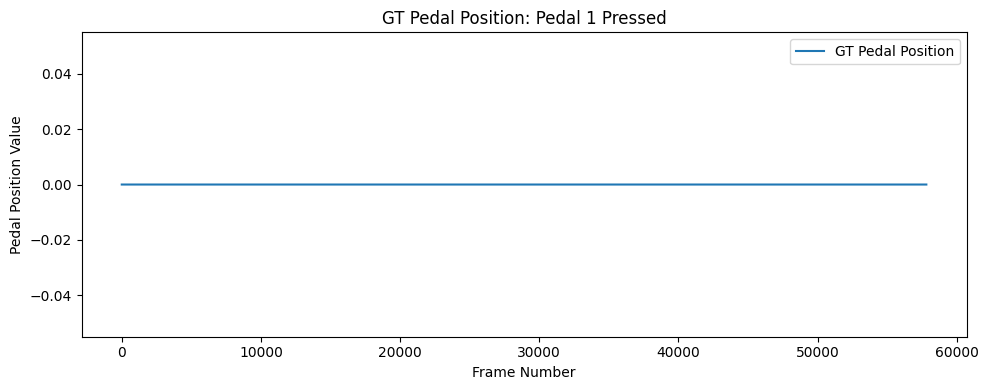

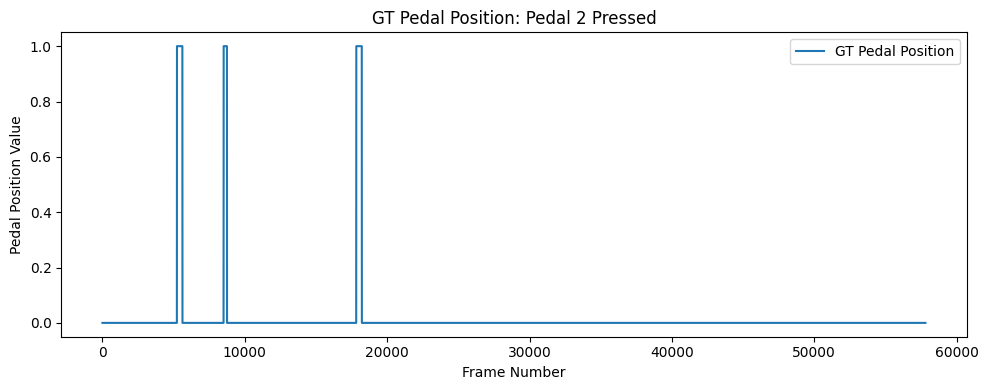

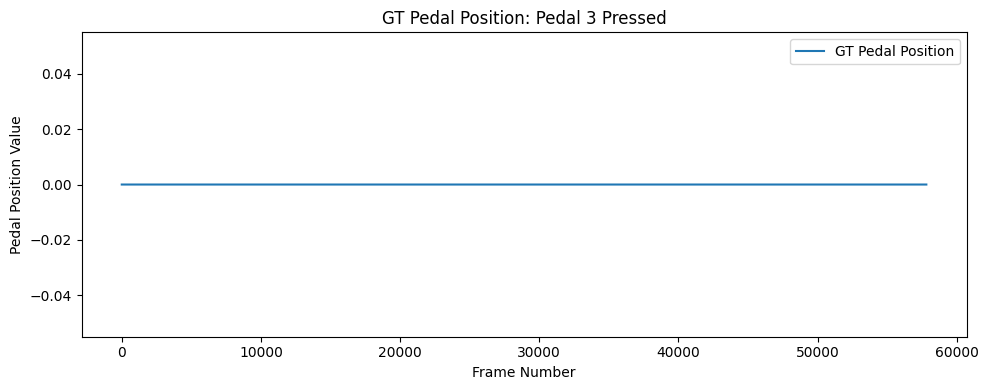

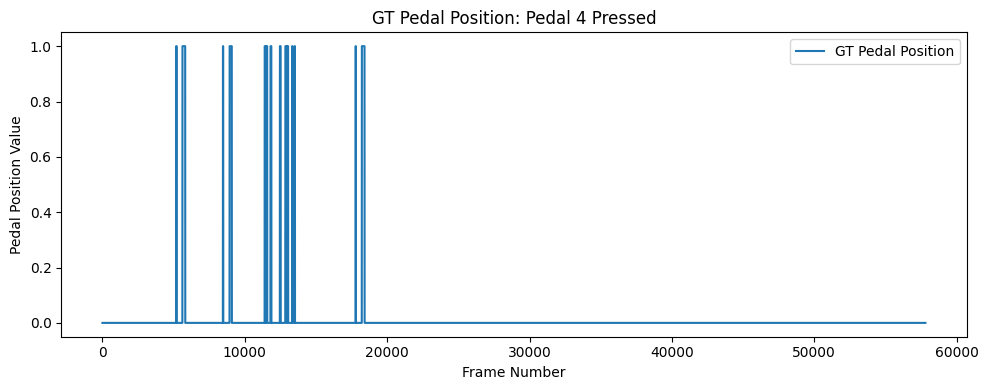

Upper Left (Pedal 1 Pressed) Pressed Percentage: 0.00%
Upper Right (Pedal 2 Pressed) Pressed Percentage: 1.75%
Lower Left (Pedal 3 Pressed) Pressed Percentage: 0.00%
Lower Right (Pedal 4 Pressed) Pressed Percentage: 1.94%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Pretty labels for plot titles/printing (do not use these as DF column names)
labels = {
    'Upper Left':  'Pedal 1 Pressed',
    'Upper Right': 'Pedal 2 Pressed',
    'Lower Left':  'Pedal 3 Pressed',
    'Lower Right': 'Pedal 4 Pressed',
}

def sGT(df, labels=labels):
    """Plot GT pedal position columns against Frame Num."""
    required = ['Frame Num'] + list(labels.keys())
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    for pedal_col, pretty in labels.items():
        plt.figure(figsize=(10, 4))
        plt.plot(df['Frame Num'], df[pedal_col], label='GT Pedal Position')
        plt.xlabel('Frame Number')
        plt.ylabel('Pedal Position Value')
        plt.title(f'GT Pedal Position: {pretty}')
        plt.legend()
        plt.tight_layout()
        plt.show()

gt_pds_trials = [
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/Bowel_S207_T2_2024-07-18",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/Bowel_S216_T1_2024-07-18",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/BOWL_ANAS_S207_T1_2024-07-17",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/BOWL_ANAS_S207_T2_2024-07-17",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/ESL_S203_T1_2024-07-16",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/ESL_S207_T1_2024-07-16",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/Gyno_S11_T1_2024-07-17",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/InguinalH_S210_T1_2024-07-17",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/PEGT_S118_T1_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/PegT_S220_T2_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S116_T1_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VentralH_S219_T1_2024-07-19",
    "/standard/UVA-DSA/MIDAS/Bootcamp_PDS_GroundTruth/VH1_S203_T1_2024-07-16",
]

# Load all trials
complete_df = pd.DataFrame()
for gt_trial in gt_pds_trials:
    csv_path = Path(gt_trial) / "pedal_detection.csv"
    if not csv_path.exists():
        print(f"[WARN] Missing file: {csv_path}")
        continue
    gt_pds_df = pd.read_csv(csv_path)
    complete_df = pd.concat([complete_df, gt_pds_df], ignore_index=True)

# Plot
sGT(complete_df, labels=labels)

# Generic percentage function
def compute_pressed_percentage(df, pedal_column):
    if pedal_column not in df.columns:
        raise KeyError(f"Column not found: {pedal_column}")
    pressed_count = df[pedal_column].sum()
    total_count = len(df)
    return (pressed_count / total_count) * 100 if total_count > 0 else 0

# Use DF column names (keys), not the pretty labels (values)
for pedal_col, pretty in labels.items():
    percentage = compute_pressed_percentage(complete_df, pedal_col)
    print(f"{pedal_col} ({pretty}) Pressed Percentage: {percentage:.2f}%")
